# **02. Exploratory Data Analysis and Feature Engineering**

This notebook performs a detailed exploratory data analysis of the Telco Customer Churn dataset and creates new features for the machine learning stage.

The main objectives are:

- Analyze churn patterns across customer demographics, contracts, billing methods, and services.
- Identify variables strongly associated with churn.
- Generate business-oriented insights.
- Create engineered features that may improve predictive performance.
- Save an enriched dataset for model training.


## 1. Introduction

Customer churn analysis is useful for identifying patterns that explain why customers leave a company. In this notebook, the focus is not only on visual exploration, but also on extracting interpretable business insights.

The analysis will pay special attention to contract type, payment method, tenure, monthly charges, internet service, and support-related services, as these variables are often closely related to customer retention.

## 2. Data Loading and Preparation

The dataset generated in the previous notebook is loaded from the `data/processed/` directory. This version already includes the initial correction of the `TotalCharges` data type.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import chi2_contingency

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

figsize = (13, 6)

In [3]:
DATA_PATH = Path("../data/processed/telco_customer_churn_initial_clean.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains customer demographic information, service subscriptions, contract and billing information, numerical charge variables, and the target variable `Churn`.

Before performing the exploratory analysis, the target variable is converted into a binary numerical variable to simplify aggregation and visualization.

In [5]:
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1})

df[["Churn", "ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [6]:
df["ChurnFlag"].value_counts(normalize=True) * 100

ChurnFlag
0   73.46
1   26.54
Name: proportion, dtype: float64

In the previous notebook, 11 missing values were detected in `TotalCharges`. These records correspond to customers with `tenure = 0`.

Since these customers have not accumulated charges yet, these missing values are replaced with 0.

In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["TotalCharges"].isnull().sum()

np.int64(0)

## 3. Exploratory Data Analysis

This section analyzes the dataset from different perspectives:

- Overall churn distribution.
- Demographic variables.
- Contract and billing variables.
- Service-related variables.
- Numerical charge and tenure variables.


### 3.1 Target Variable

The first step is to analyze the distribution of the target variable.

In [8]:
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_percentages.round(2)
})

target_summary

,count,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


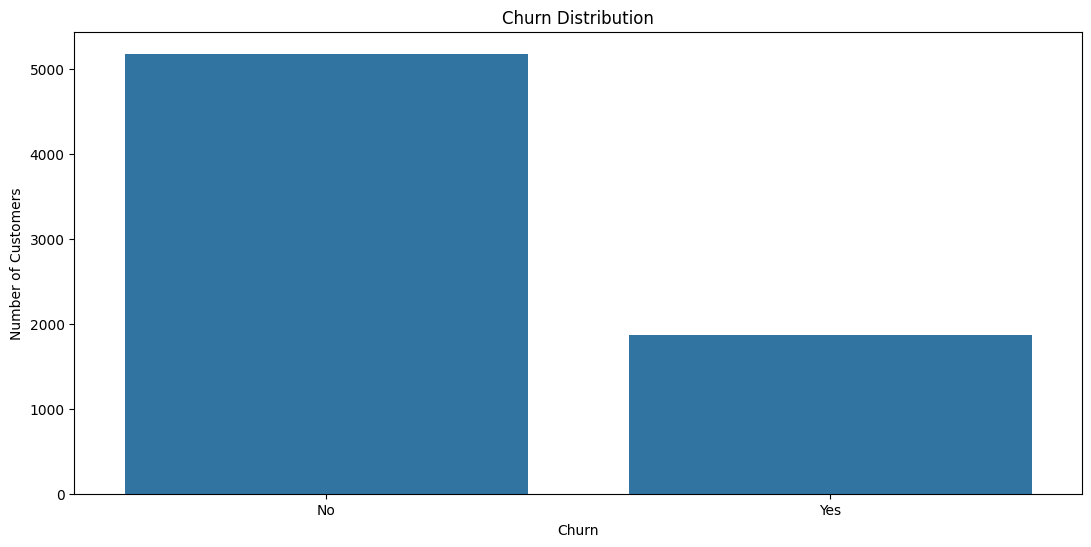

In [9]:
plt.figure(figsize=figsize)
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

The target variable is clearly imbalanced. Most customers did not churn, while approximately one quarter of the customers left the company.

This means that accuracy should not be the only evaluation metric in the modeling stage. Recall, precision, F1-score, ROC-AUC, and confusion matrix will be more informative.

### 3.2 Demographic Variables

This section analyzes whether demographic variables are associated with customer churn.

In [10]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype(object)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

demographic_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

for col in demographic_columns:
    display(
        df.groupby(col)["ChurnFlag"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "churn_rate"})
        .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(2))
        .sort_values("churn_rate", ascending=False)
    )

,count,churn_rate
gender,,
Female,3488,26.92
Male,3555,26.16


,count,churn_rate
SeniorCitizen,,
Yes,1142,41.68
No,5901,23.61


,count,churn_rate
Partner,,
No,3641,32.96
Yes,3402,19.66


,count,churn_rate
Dependents,,
No,4933,31.28
Yes,2110,15.45


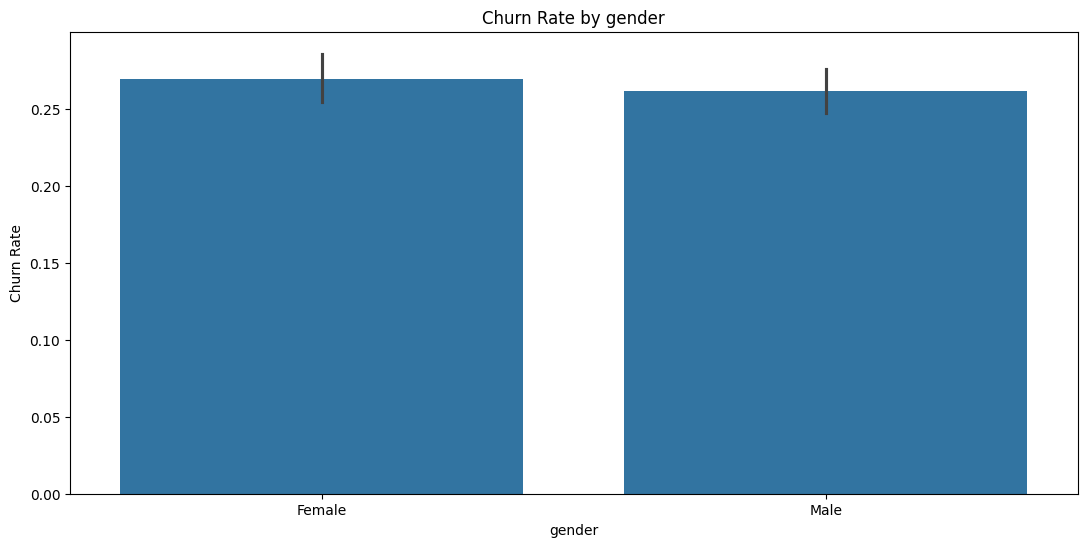

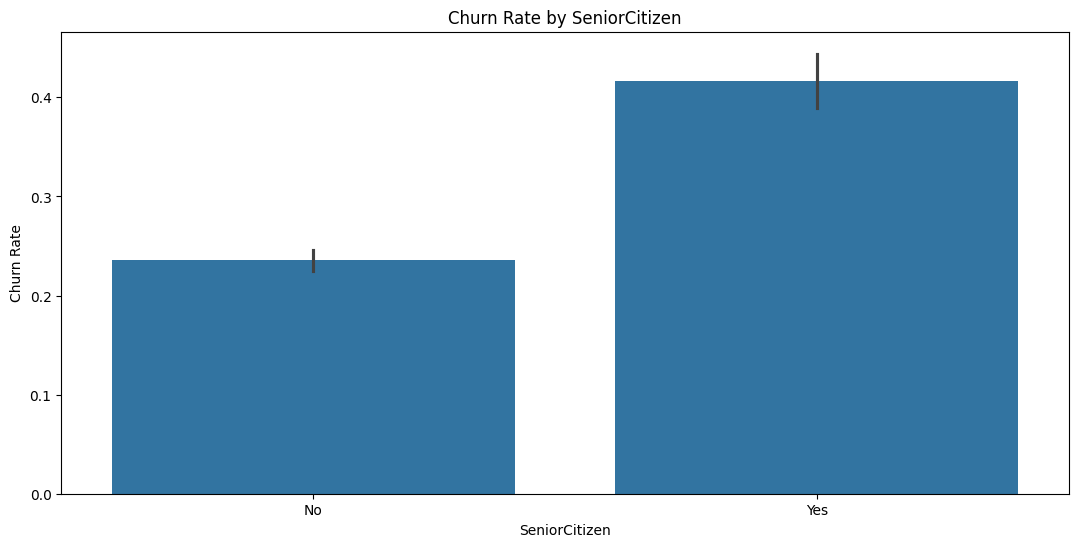

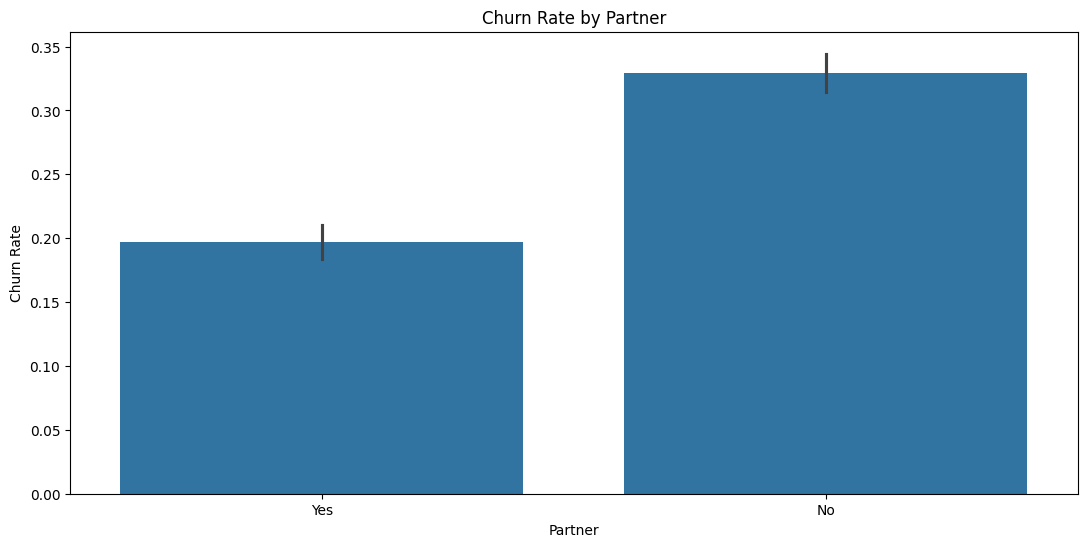

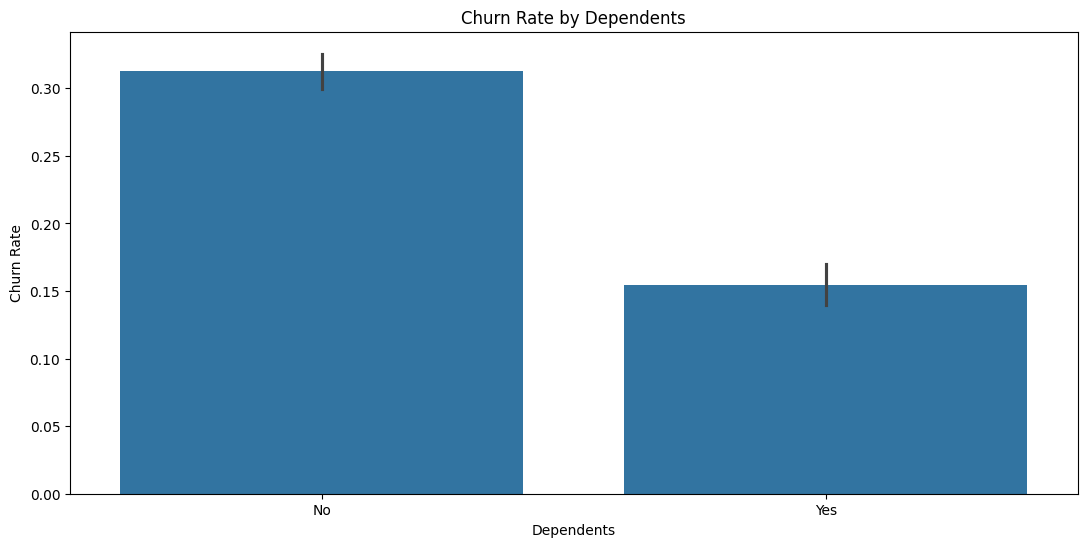

In [11]:
for col in demographic_columns:
    plt.figure(figsize=figsize)
    sns.barplot(data=df, x=col, y="ChurnFlag", estimator=np.mean)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.show()

Initial demographic insights:

- Gender does not show a meaningful difference in churn rate.
- Senior citizens show a higher churn rate than non-senior customers.
- Customers without a partner have a higher churn rate.
- Customers without dependents also show a higher churn rate.

These variables may contribute to the model, although the strongest churn drivers are expected to come from contract, billing, tenure, and service-related variables.

### 3.3 Contract and Billing Variables

Contract and billing features are especially relevant because they are directly related to customer commitment and payment behavior.

In [12]:
contract_billing_columns = [
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in contract_billing_columns:
    display(
        df.groupby(col)["ChurnFlag"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "churn_rate"})
        .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(2))
        .sort_values("churn_rate", ascending=False)
    )

,count,churn_rate
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83


,count,churn_rate
PaperlessBilling,,
Yes,4171,33.57
No,2872,16.33


,count,churn_rate
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24


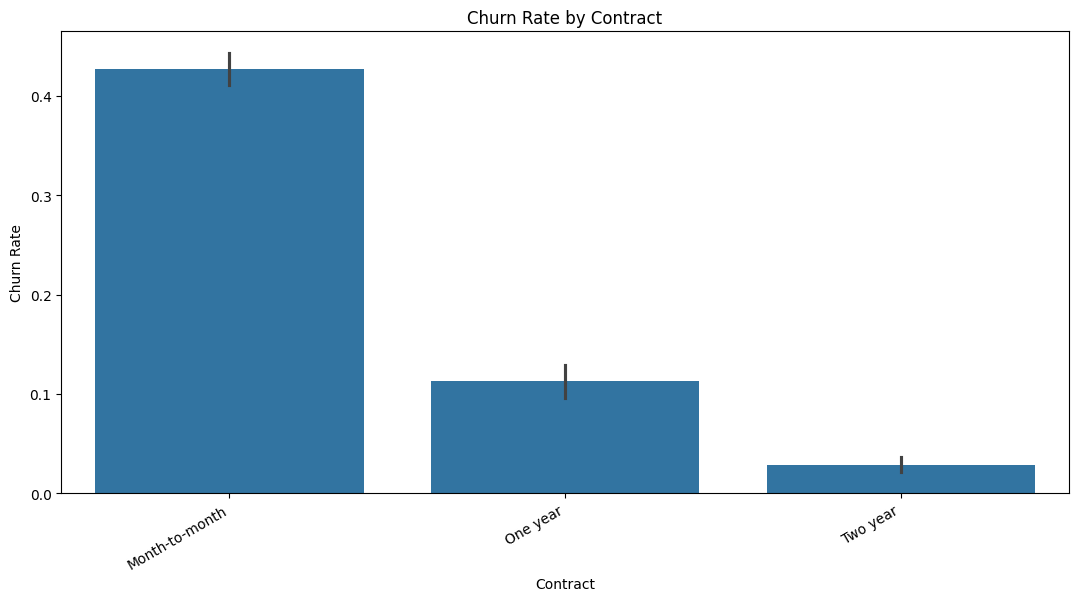

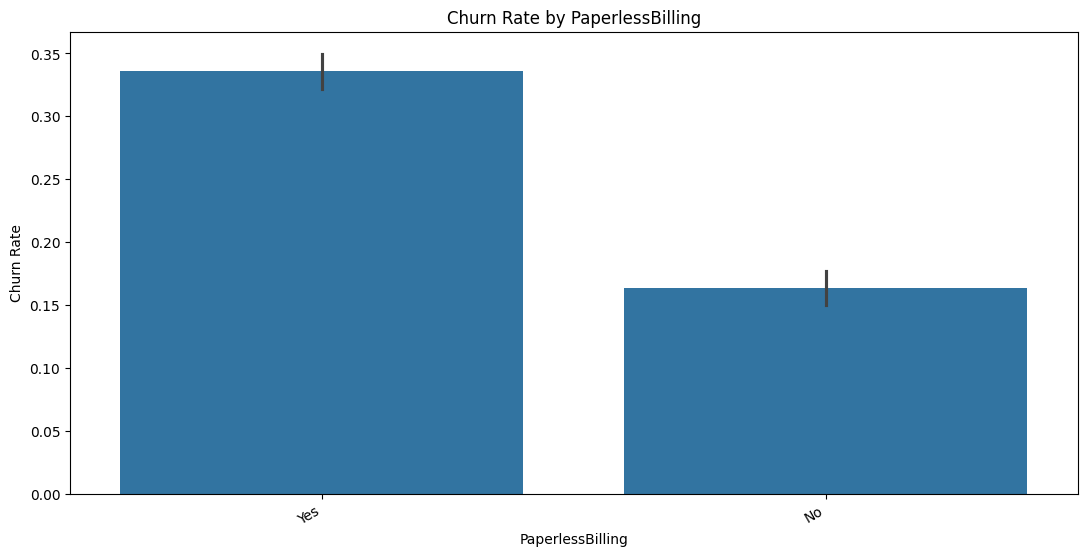

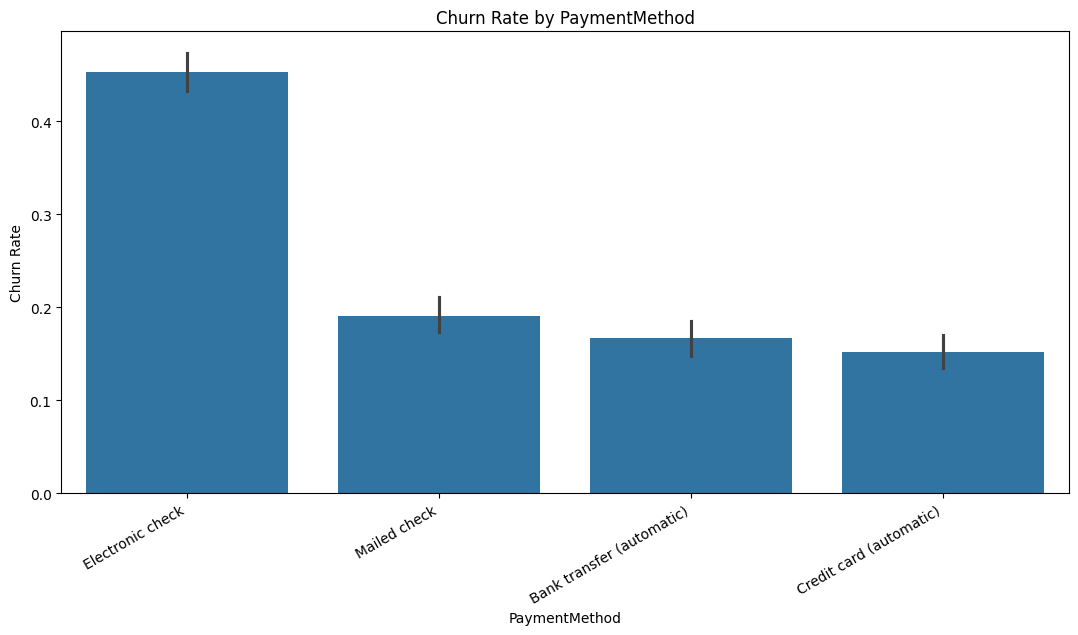

In [13]:
for col in contract_billing_columns:
    plt.figure(figsize=figsize)
    sns.barplot(data=df, x=col, y="ChurnFlag", estimator=np.mean)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=30, ha="right")
    plt.show()

Contract and billing insights:

- Customers with month-to-month contracts have a much higher churn rate.
- Customers with one-year and two-year contracts are significantly more stable.
- Paperless billing is associated with higher churn.
- Electronic check is the payment method with the highest churn rate.

These variables are likely to be among the most relevant predictors in the machine learning stage.

### 3.4 Service-Related Variables

This section analyzes the relationship between subscribed services and churn.

In [14]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_columns:
    display(
        df.groupby(col)["ChurnFlag"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "churn_rate"})
        .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(2))
        .sort_values("churn_rate", ascending=False)
    )

,count,churn_rate
PhoneService,,
Yes,6361,26.71
No,682,24.93


,count,churn_rate
MultipleLines,,
Yes,2971,28.61
No,3390,25.04
No phone service,682,24.93


,count,churn_rate
InternetService,,
Fiber optic,3096,41.89
DSL,2421,18.96
No,1526,7.40


,count,churn_rate
OnlineSecurity,,
No,3498,41.77
Yes,2019,14.61
No internet service,1526,7.40


,count,churn_rate
OnlineBackup,,
No,3088,39.93
Yes,2429,21.53
No internet service,1526,7.40


,count,churn_rate
DeviceProtection,,
No,3095,39.13
Yes,2422,22.50
No internet service,1526,7.40


,count,churn_rate
TechSupport,,
No,3473,41.64
Yes,2044,15.17
No internet service,1526,7.40


,count,churn_rate
StreamingTV,,
No,2810,33.52
Yes,2707,30.07
No internet service,1526,7.40


,count,churn_rate
StreamingMovies,,
No,2785,33.68
Yes,2732,29.94
No internet service,1526,7.40


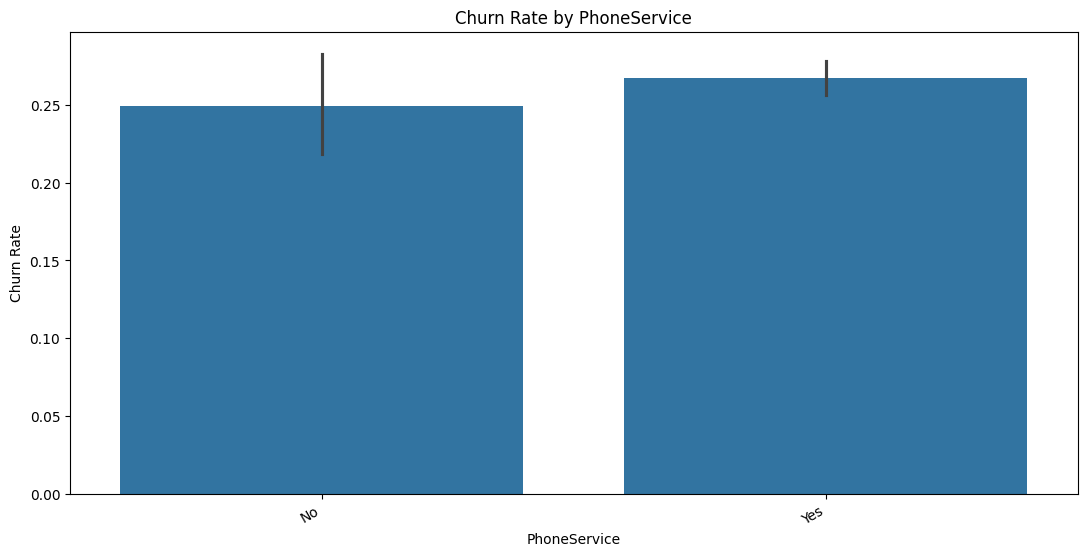

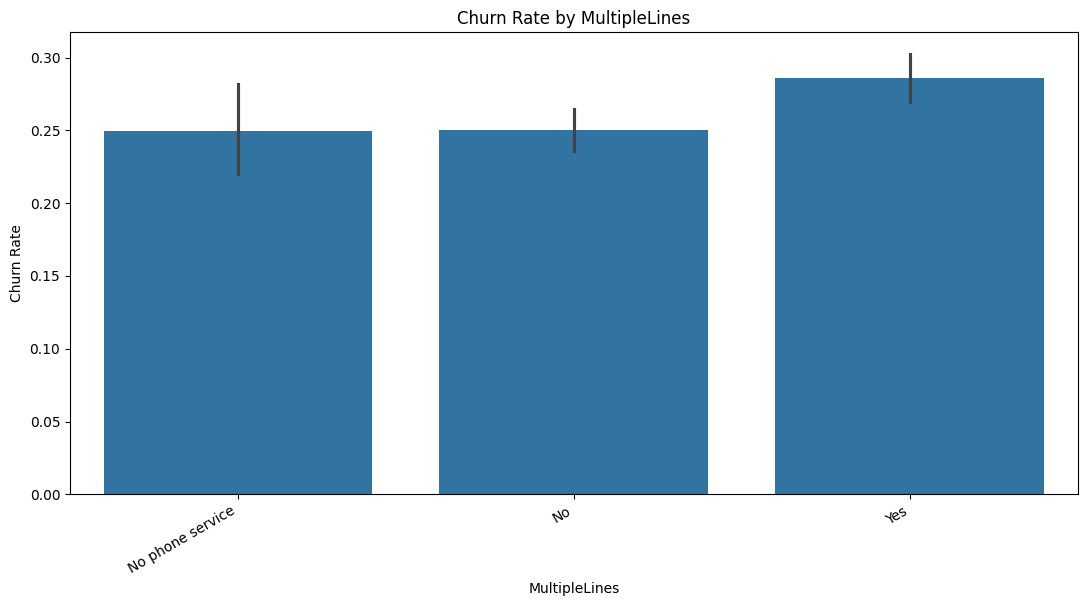

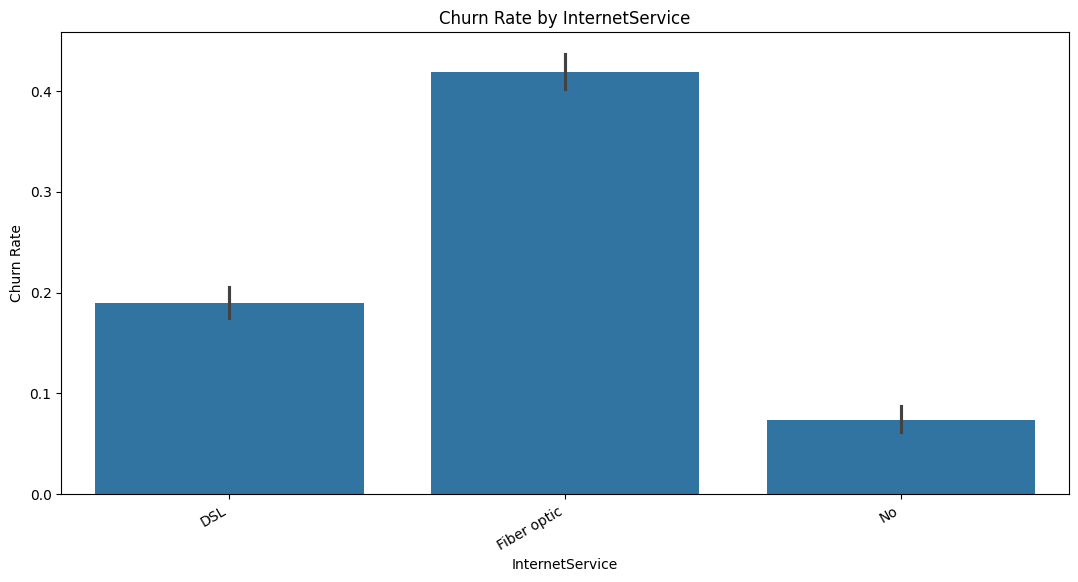

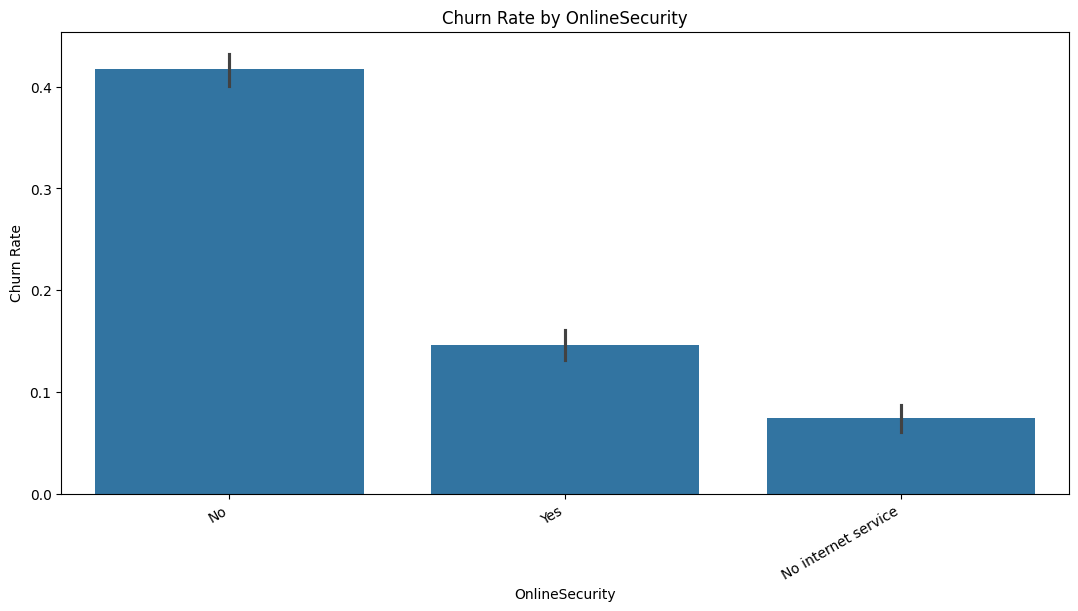

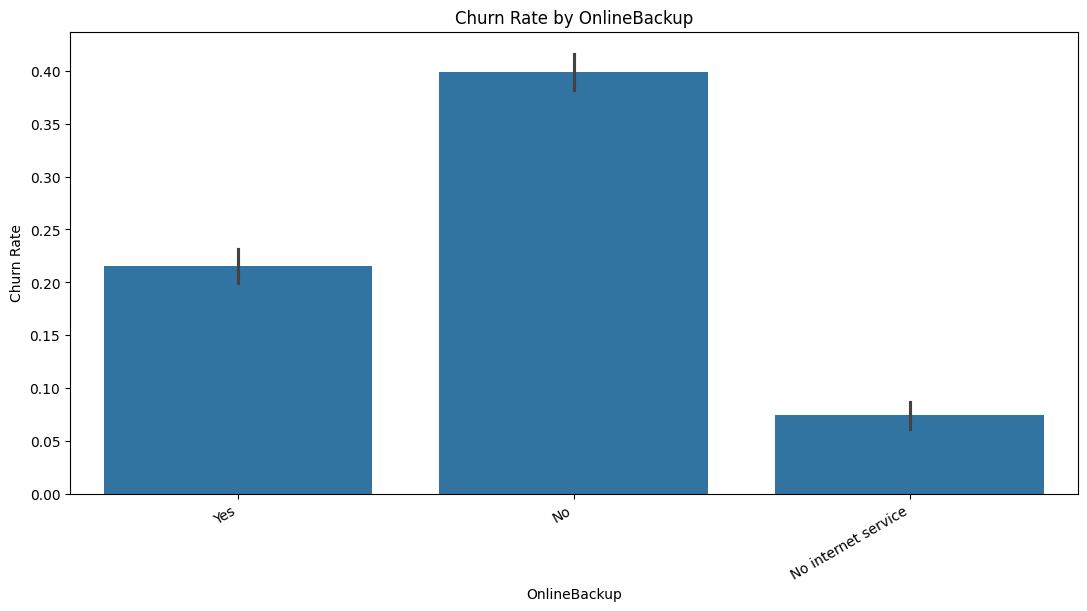

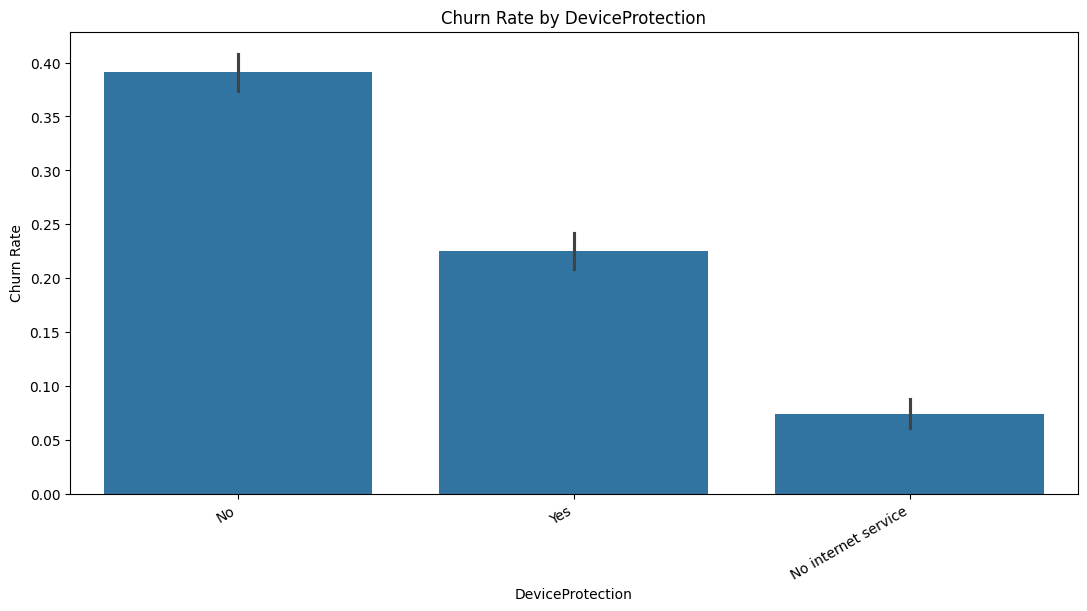

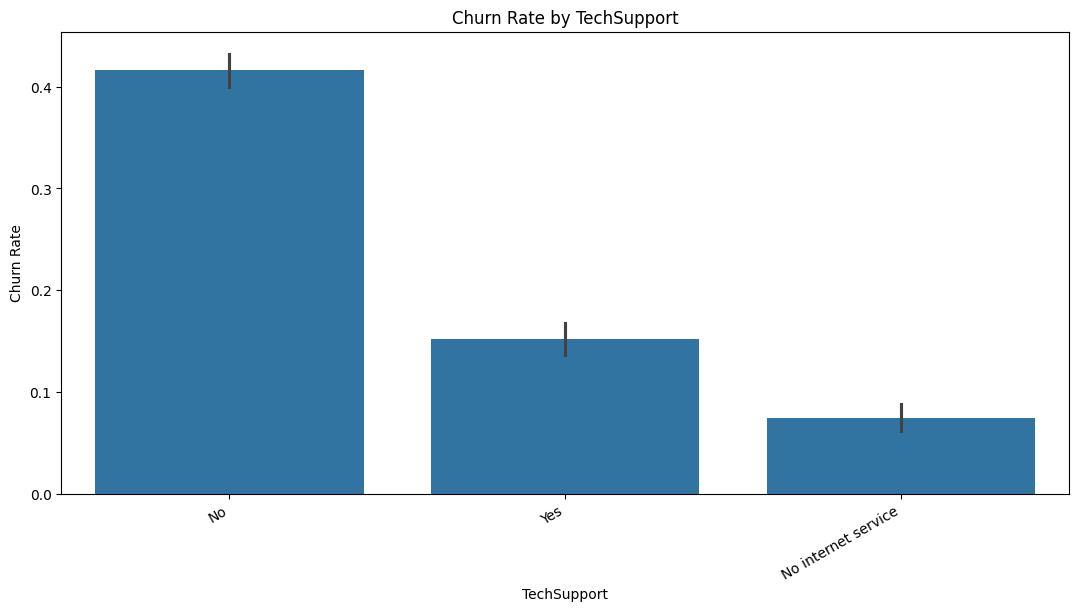

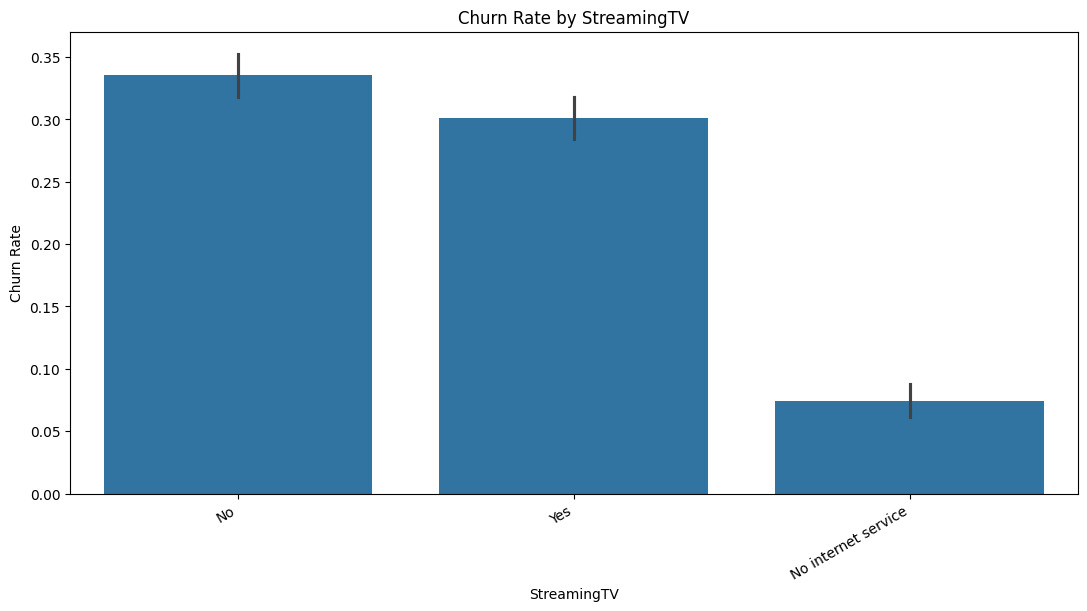

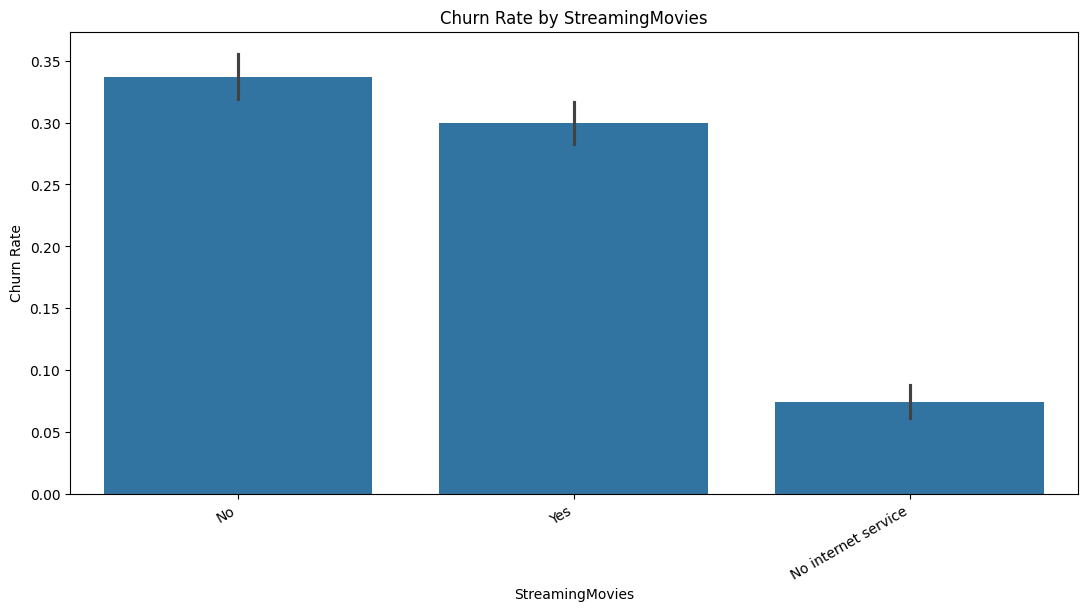

In [15]:
for col in service_columns:
    plt.figure(figsize=figsize)
    sns.barplot(data=df, x=col, y="ChurnFlag", estimator=np.mean)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=30, ha="right")
    plt.show()

Service-related insights:

- Customers with fiber optic internet show a higher churn rate than customers with DSL or no internet service.
- Customers without online security have a much higher churn rate.
- Customers without tech support also show a high churn rate.
- Customers without internet service have the lowest churn rate.
- Streaming services alone do not seem to reduce churn significantly.

Support and security services appear to be more relevant for retention than entertainment services.

### 3.5 Numerical Variables

This section analyzes numerical variables: `tenure`, `MonthlyCharges`, and `TotalCharges`.

In [16]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.00,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80


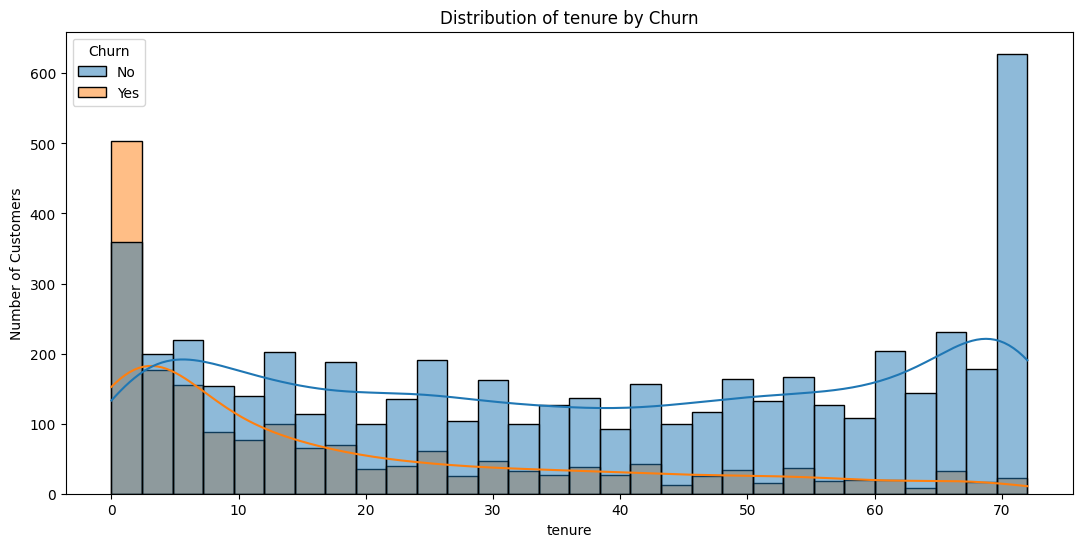

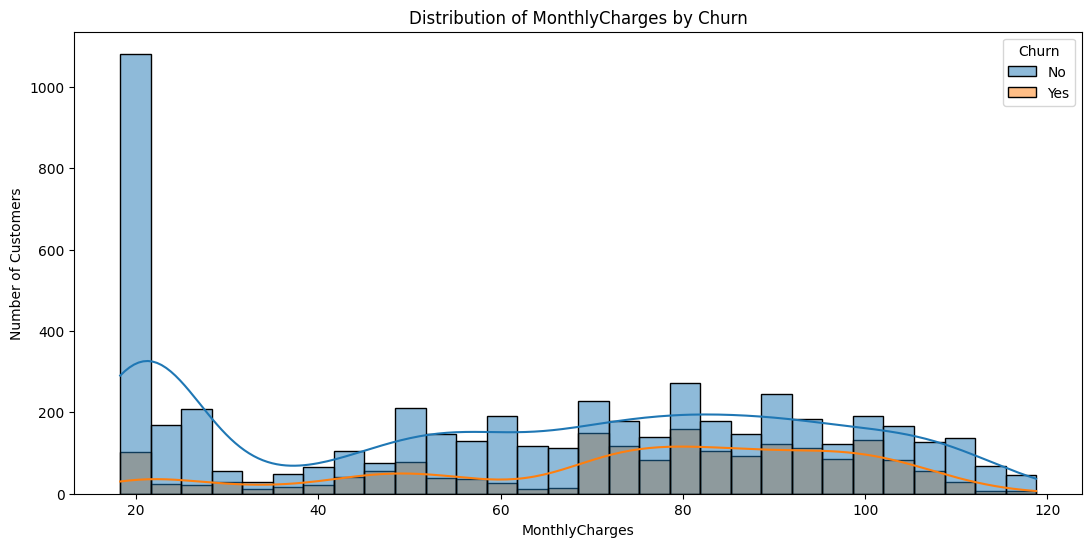

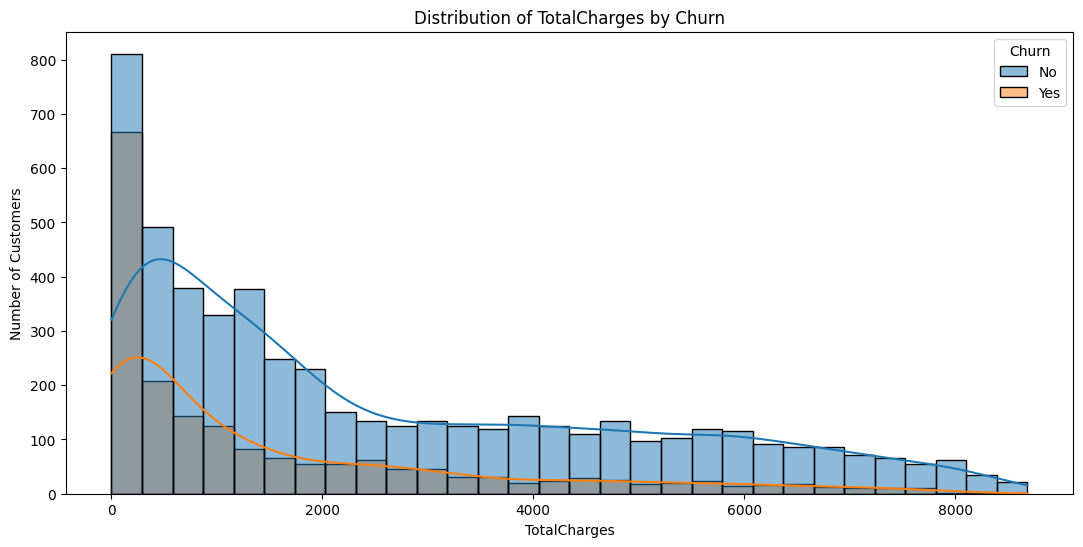

In [17]:
for col in numerical_columns:
    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=col, hue="Churn", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Churn")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.show()

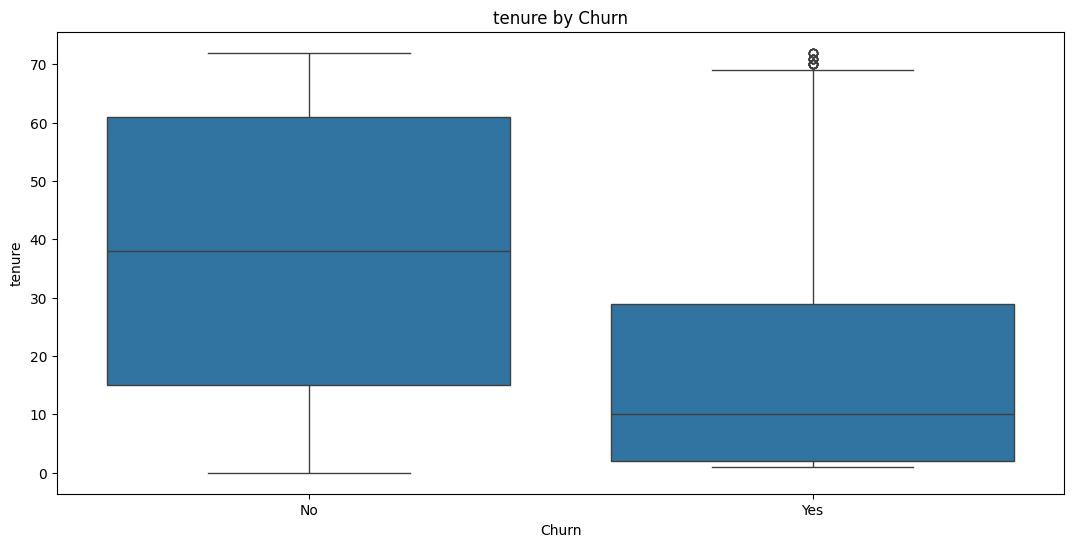

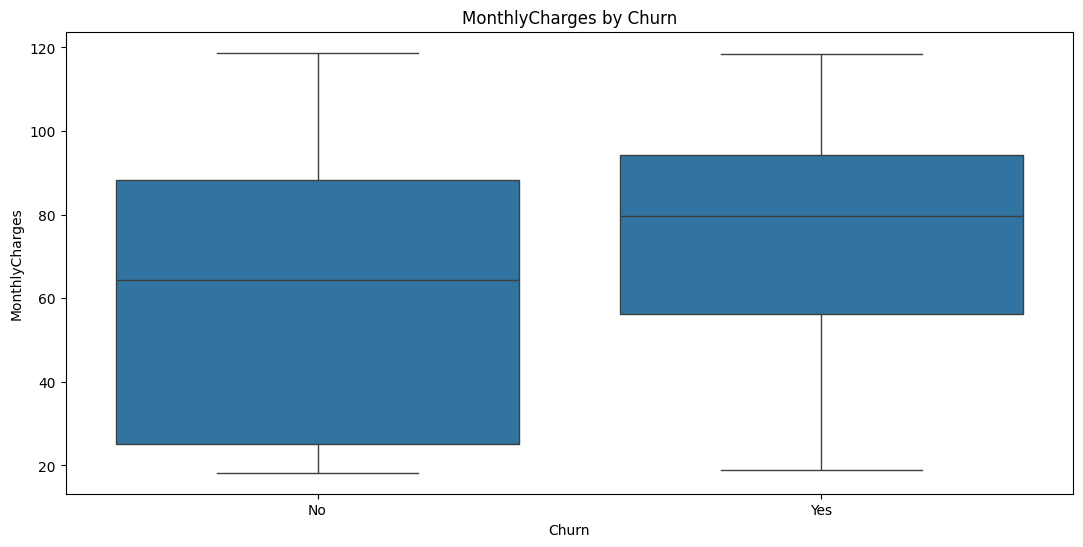

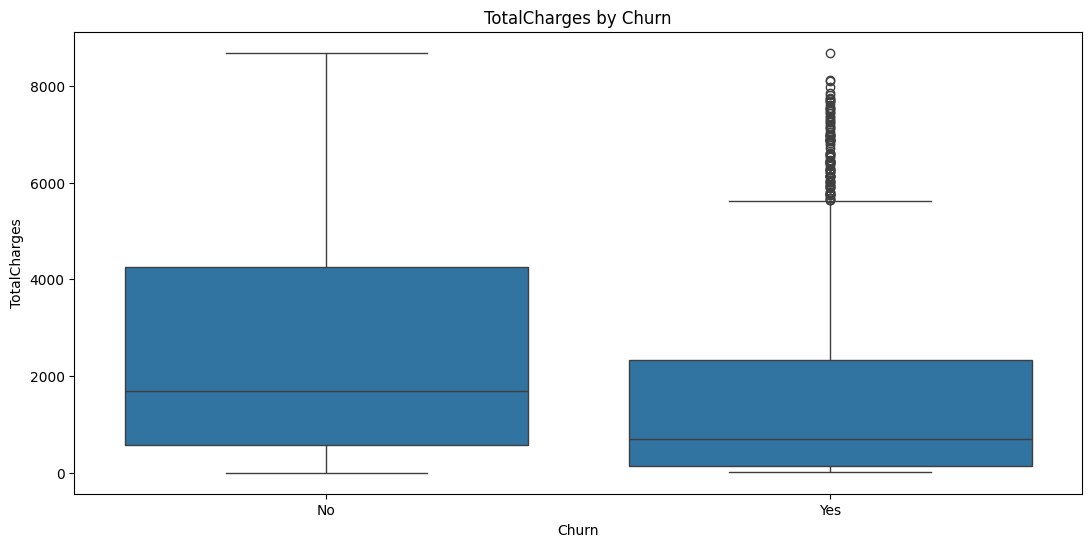

In [18]:
for col in numerical_columns:
    plt.figure(figsize=figsize)
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [19]:
df.groupby("Churn")[numerical_columns].mean().T

Churn,No,Yes
tenure,37.57,17.98
MonthlyCharges,61.27,74.44
TotalCharges,2549.91,1531.80


Numerical variable insights:

- Customers who churn tend to have lower tenure.
- Customers who churn tend to have higher monthly charges.
- Customers who do not churn tend to have higher total charges, mainly because they have stayed longer with the company.
- `tenure` is expected to be one of the strongest predictors because customers who leave usually do so earlier in their lifecycle.

## 4. Correlation and Association Analysis

This section analyzes the relationship between churn and the main numerical, demographic, contract, billing, and service-related variables.

Since the dataset contains both numerical and categorical variables, different approaches are used:

- Pearson correlation for numerical variables.
- Cramér's V for categorical variables.
- One-hot encoded correlation with `ChurnFlag` to inspect the relationship between individual categories and churn.

### 4.1 Numerical Correlation

The following analysis calculates the Pearson correlation between numerical variables and the target variable.

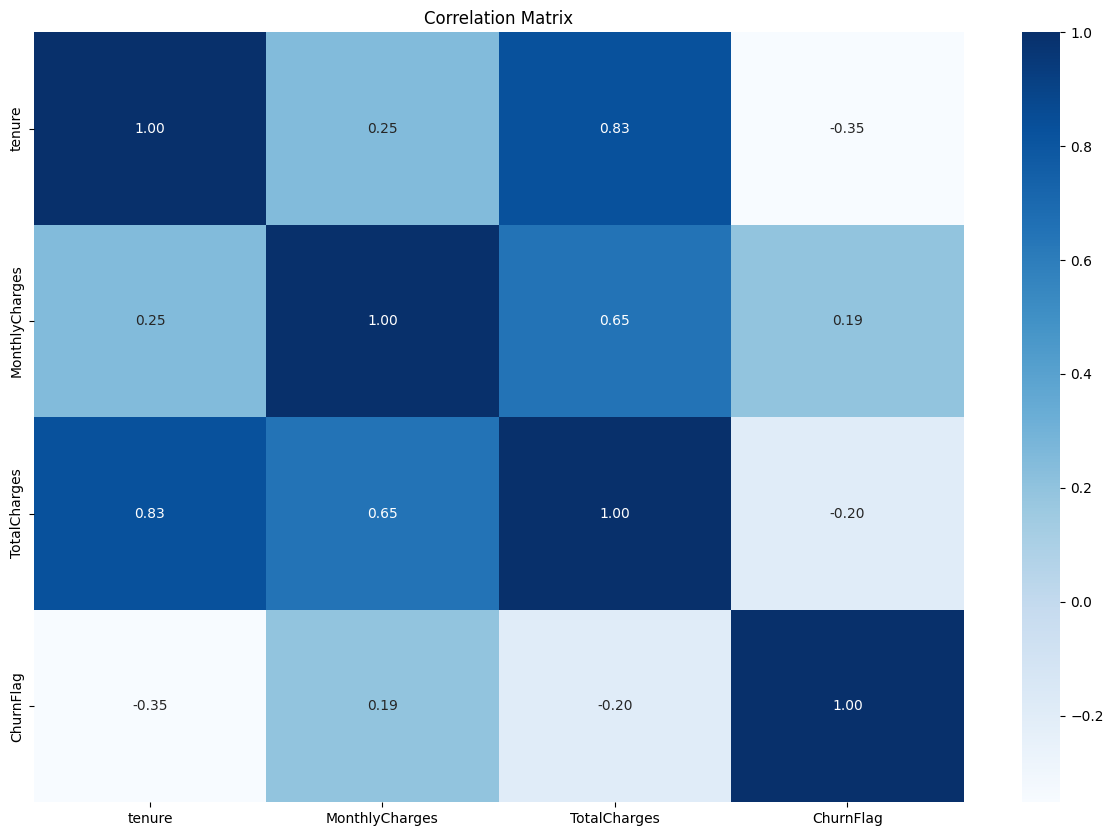

In [20]:
correlation_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnFlag"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [21]:
correlation_with_churn = (
    correlation_matrix["ChurnFlag"]
    .drop("ChurnFlag")
    .sort_values(ascending=False)
)

correlation_with_churn

MonthlyCharges    0.19
TotalCharges     -0.20
tenure           -0.35
Name: ChurnFlag, dtype: float64

The numerical correlation analysis suggests that:

- `tenure` has a negative relationship with churn.
- `MonthlyCharges` has a positive relationship with churn.
- `TotalCharges` has a negative relationship with churn, mainly because it is related to longer customer tenure.

However, many important churn drivers are categorical, so the model will need proper categorical encoding in the next stages.


### 4.2 Categorical Association with Churn using Cramér's V

Most demographic, contract, billing, and service-related variables are categorical. For this reason, Cramér's V is used to measure the strength of association between each categorical variable and the target variable.

Cramér's V ranges from 0 to 1:

- Values close to 0 indicate weak association.
- Values closer to 1 indicate stronger association.


In [22]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    
    r, k = confusion_matrix.shape
    
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

In [23]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

cramers_results = []

for col in categorical_features:
    score = cramers_v(df[col], df["Churn"])
    cramers_results.append({
        "feature": col,
        "cramers_v": score
    })

cramers_df = (
    pd.DataFrame(cramers_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

cramers_df

,feature,cramers_v
0,Contract,0.41
1,OnlineSecurity,0.35
2,TechSupport,0.34
3,InternetService,0.32
4,PaymentMethod,0.30
5,OnlineBackup,0.29
6,DeviceProtection,0.28
7,StreamingMovies,0.23
8,StreamingTV,0.23
9,PaperlessBilling,0.19


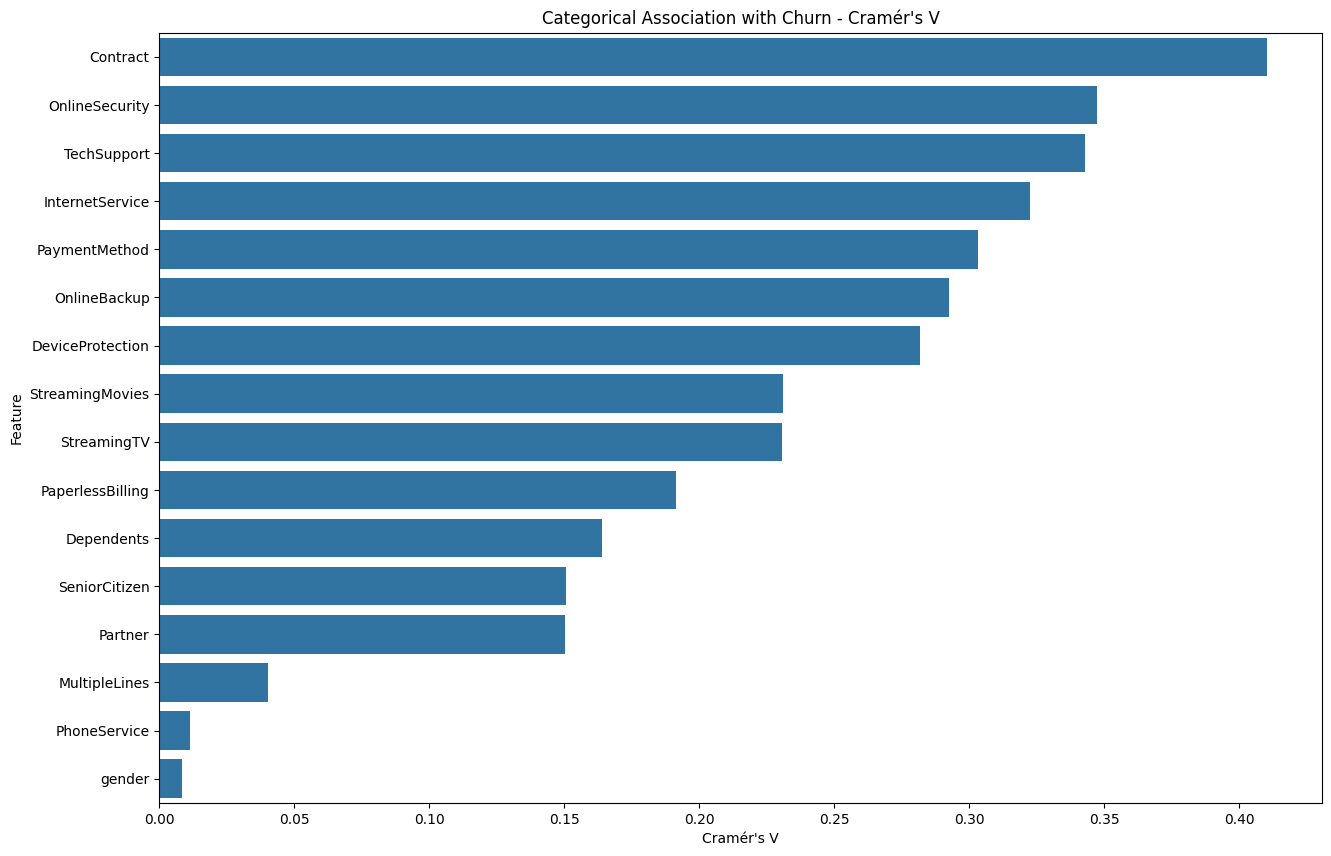

In [24]:
plt.figure(figsize=(15, 10))
sns.barplot(data=cramers_df, x="cramers_v", y="feature")
plt.title("Categorical Association with Churn - Cramér's V")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.show()

Cramér's V allows us to compare the association strength between categorical variables and churn.

Variables such as `Contract`, `OnlineSecurity`, `TechSupport`, `InternetService`, and `PaymentMethod` are expected to show stronger association with churn than demographic variables such as `gender`.

This supports the idea that churn is more strongly related to contract conditions, billing behavior, and service experience than to basic demographic characteristics.

### 4.3 One-Hot Encoded Feature Correlation with Churn

To identify which specific categories are positively or negatively associated with churn, categorical variables are one-hot encoded and correlated with `ChurnFlag`.

In [25]:
demographic_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

contract_billing_features = [
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


features_for_encoding = demographic_features + contract_billing_features + service_features

encoded_df = pd.get_dummies(
    df[features_for_encoding],
    drop_first=False
)

encoded_df["ChurnFlag"] = df["ChurnFlag"]

encoded_df.head()

,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,ChurnFlag
0,True,False,True,False,False,True,True,False,True,False,False,False,True,False,False,True,False,True,False,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,0
1,False,True,True,False,True,False,True,False,False,True,False,True,False,False,False,False,True,False,True,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,0
2,False,True,True,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False,True,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,1
3,False,True,True,False,True,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,0
4,True,False,True,False,True,False,True,False,True,False,False,False,True,False,False,True,False,False,True,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,1


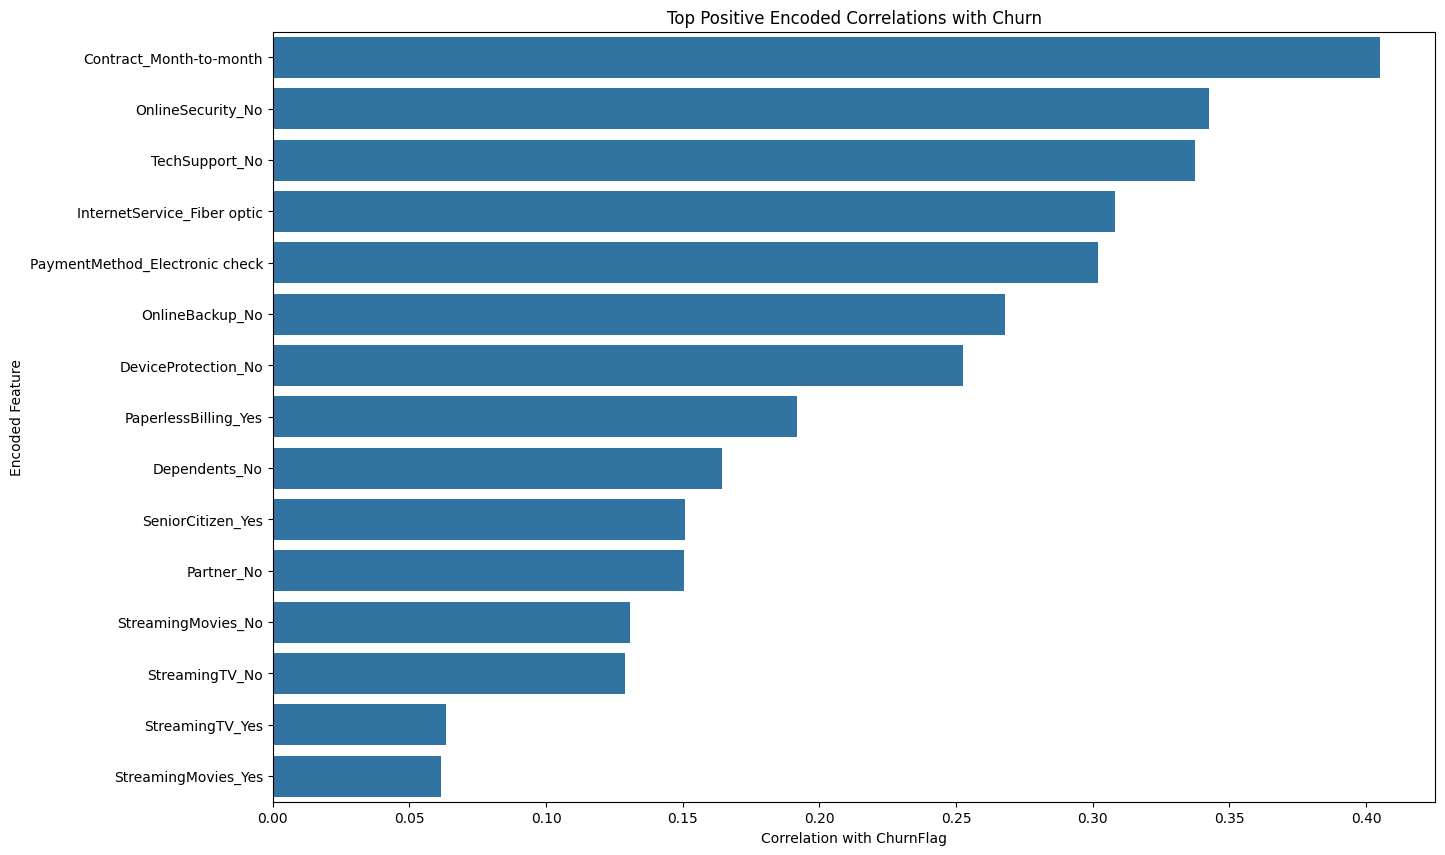

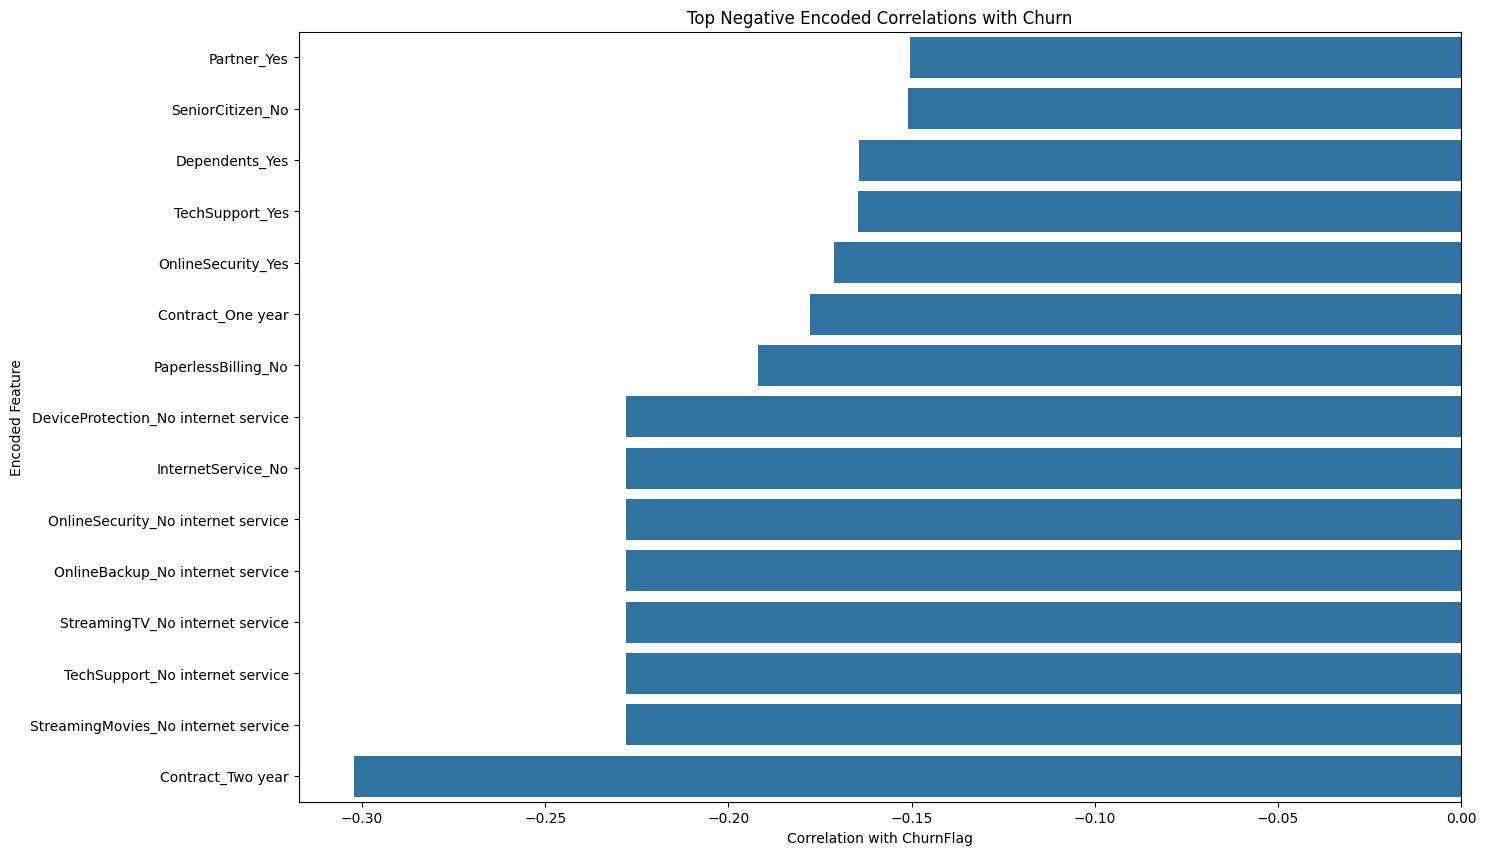

In [26]:
encoded_correlations = (
    encoded_df.corr()["ChurnFlag"]
    .drop("ChurnFlag")
    .sort_values(ascending=False)
)

top_positive_corr = encoded_correlations.head(15)
top_negative_corr = encoded_correlations.tail(15)

plt.figure(figsize=(15, 10))
sns.barplot(x=top_positive_corr.values, y=top_positive_corr.index)
plt.title("Top Positive Encoded Correlations with Churn")
plt.xlabel("Correlation with ChurnFlag")
plt.ylabel("Encoded Feature")
plt.show()

plt.figure(figsize=(15, 10))
sns.barplot(x=top_negative_corr.values, y=top_negative_corr.index)
plt.title("Top Negative Encoded Correlations with Churn")
plt.xlabel("Correlation with ChurnFlag")
plt.ylabel("Encoded Feature")
plt.show()

The one-hot encoded correlation analysis helps identify specific categories associated with churn.

Positive correlations indicate categories associated with higher churn probability, while negative correlations indicate categories associated with lower churn probability.

Expected high-risk categories include:

- Month-to-month contracts.
- Electronic check payment.
- Fiber optic internet service.
- Lack of online security.
- Lack of tech support.

Expected low-risk categories include:

- Two-year contracts.
- One-year contracts.
- No internet service.
- Automatic payment methods.


### 4.5 Main Churn Drivers Summary

The following table summarizes the strongest categorical associations with churn.

In [27]:
main_churn_drivers = cramers_df.copy()

main_churn_drivers["association_strength"] = pd.cut(
    main_churn_drivers["cramers_v"],
    bins=[0, 0.1, 0.2, 0.3, 1.0],
    labels=[
        "Very weak",
        "Weak",
        "Moderate",
        "Strong"
    ],
    include_lowest=True
)

main_churn_drivers

,feature,cramers_v,association_strength
0,Contract,0.41,Strong
1,OnlineSecurity,0.35,Strong
2,TechSupport,0.34,Strong
3,InternetService,0.32,Strong
4,PaymentMethod,0.30,Strong
5,OnlineBackup,0.29,Moderate
6,DeviceProtection,0.28,Moderate
7,StreamingMovies,0.23,Moderate
8,StreamingTV,0.23,Moderate
9,PaperlessBilling,0.19,Weak


## 5. Feature Engineering

This section creates new variables that summarize customer behavior, contract risk, service adoption, payment behavior, and customer value.

The engineered features are designed to make relevant business patterns easier for machine learning models to capture.

In [28]:
df_fe = df.copy()

df_fe.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


### 5.1 Tenure Groups

Customer tenure is transformed into groups to represent different stages of the customer lifecycle.

In [29]:
df_fe["tenure_group"] = pd.cut(
    df_fe["tenure"],
    bins=[-1, 0, 12, 24, 48, 60, 72],
    labels=[
        "New customer",
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-60 months",
        "61-72 months"
    ]
)

df_fe[["tenure", "tenure_group"]].head()

,tenure,tenure_group
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months


In [30]:
df_fe.groupby("tenure_group", observed=False)["ChurnFlag"].mean().mul(100).round(2)

tenure_group
New customer    0.00
0-12 months    47.68
13-24 months   28.71
25-48 months   20.39
49-60 months   14.42
61-72 months    6.61
Name: ChurnFlag, dtype: float64

### 5.2 Charge Segments

Monthly charges are grouped into low, medium, high, and very high segments. This can help identify whether expensive plans are associated with higher churn.

In [31]:
df_fe["monthly_charge_segment"] = pd.qcut(
    df_fe["MonthlyCharges"],
    q=4,
    labels=[
        "Low monthly charge",
        "Medium monthly charge",
        "High monthly charge",
        "Very high monthly charge"
    ]
)

df_fe[["MonthlyCharges", "monthly_charge_segment"]].head()

,MonthlyCharges,monthly_charge_segment
0,29.85,Low monthly charge
1,56.95,Medium monthly charge
2,53.85,Medium monthly charge
3,42.30,Medium monthly charge
4,70.70,High monthly charge


In [32]:
df_fe.groupby("monthly_charge_segment", observed=False)["ChurnFlag"].mean().mul(100).round(2)

monthly_charge_segment
Low monthly charge         11.24
Medium monthly charge      24.58
High monthly charge        37.51
Very high monthly charge   32.88
Name: ChurnFlag, dtype: float64

### 5.3 Internet and Service Indicators

Several binary indicators are created to summarize internet availability, support services, security services, and streaming services.

In [33]:
df_fe["has_internet_service"] = np.where(
    df_fe["InternetService"] == "No",
    0,
    1
)

df_fe["has_fiber_optic"] = np.where(
    df_fe["InternetService"] == "Fiber optic",
    1,
    0
)

df_fe["has_online_security"] = np.where(
    df_fe["OnlineSecurity"] == "Yes",
    1,
    0
)

df_fe["has_tech_support"] = np.where(
    df_fe["TechSupport"] == "Yes",
    1,
    0
)

df_fe["has_security_or_support"] = np.where(
    (df_fe["OnlineSecurity"] == "Yes") | (df_fe["TechSupport"] == "Yes"),
    1,
    0
)

df_fe["has_streaming_service"] = np.where(
    (df_fe["StreamingTV"] == "Yes") | (df_fe["StreamingMovies"] == "Yes"),
    1,
    0
)

df_fe[
    [
        "InternetService",
        "has_internet_service",
        "has_fiber_optic",
        "has_online_security",
        "has_tech_support",
        "has_security_or_support",
        "has_streaming_service"
    ]
].head()

,InternetService,has_internet_service,has_fiber_optic,has_online_security,has_tech_support,has_security_or_support,has_streaming_service
0,DSL,1,0,0,0,0,0
1,DSL,1,0,1,0,1,0
2,DSL,1,0,1,0,1,0
3,DSL,1,0,1,1,1,0
4,Fiber optic,1,1,0,0,0,0


In [34]:
internet_indicator_columns = [
    "has_internet_service",
    "has_fiber_optic",
    "has_online_security",
    "has_tech_support",
    "has_security_or_support",
    "has_streaming_service"
]

df_fe[internet_indicator_columns + ["ChurnFlag"]].corr()["ChurnFlag"].sort_values(ascending=False)

ChurnFlag                  1.00
has_fiber_optic            0.31
has_internet_service       0.23
has_streaming_service      0.09
has_tech_support          -0.16
has_online_security       -0.17
has_security_or_support   -0.18
Name: ChurnFlag, dtype: float64

### 5.4 Number of Subscribed Services

A new variable is created to count how many optional services each customer has. This variable can represent the level of customer engagement with the company.

In [35]:
optional_service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_fe["num_optional_services"] = (
    df_fe[optional_service_columns] == "Yes"
).sum(axis=1)

df_fe[optional_service_columns + ["num_optional_services"]].head()

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,num_optional_services
0,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,No,No,2
2,Yes,Yes,No,No,No,No,2
3,Yes,No,Yes,Yes,No,No,3
4,No,No,No,No,No,No,0


In [36]:
df_fe.groupby("num_optional_services")["ChurnFlag"].mean().mul(100).round(2)

num_optional_services
0   21.41
1   45.76
2   35.82
3   27.37
4   22.30
5   12.43
6    5.28
Name: ChurnFlag, dtype: float64

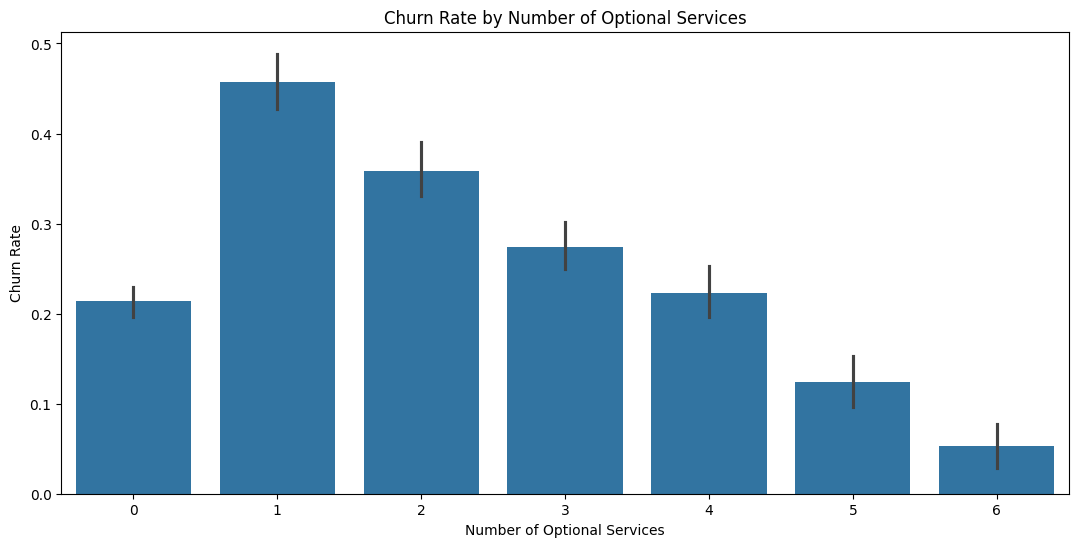

In [37]:
plt.figure(figsize=figsize)
sns.barplot(data=df_fe, x="num_optional_services", y="ChurnFlag", estimator=np.mean)
plt.title("Churn Rate by Number of Optional Services")
plt.xlabel("Number of Optional Services")
plt.ylabel("Churn Rate")
plt.show()

### 5.5 Contract and Payment Risk Indicators

Several binary variables are created to capture contract and payment-related risk patterns.

In [38]:
df_fe["is_month_to_month"] = np.where(
    df_fe["Contract"] == "Month-to-month",
    1,
    0
)

df_fe["has_long_term_contract"] = np.where(
    df_fe["Contract"].isin(["One year", "Two year"]),
    1,
    0
)

df_fe["uses_electronic_check"] = np.where(
    df_fe["PaymentMethod"] == "Electronic check",
    1,
    0
)

df_fe["uses_automatic_payment"] = np.where(
    df_fe["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]),
    1,
    0
)

df_fe[
    [
        "Contract",
        "PaymentMethod",
        "is_month_to_month",
        "has_long_term_contract",
        "uses_electronic_check",
        "uses_automatic_payment"
    ]
].head()

,Contract,PaymentMethod,is_month_to_month,has_long_term_contract,uses_electronic_check,uses_automatic_payment
0,Month-to-month,Electronic check,1,0,1,0
1,One year,Mailed check,0,1,0,0
2,Month-to-month,Mailed check,1,0,0,0
3,One year,Bank transfer (automatic),0,1,0,1
4,Month-to-month,Electronic check,1,0,1,0


In [39]:
contract_payment_indicators = [
    "is_month_to_month",
    "has_long_term_contract",
    "uses_electronic_check",
    "uses_automatic_payment"
]

df_fe[contract_payment_indicators + ["ChurnFlag"]].corr()["ChurnFlag"].sort_values(ascending=False)

ChurnFlag                 1.00
is_month_to_month         0.41
uses_electronic_check     0.30
uses_automatic_payment   -0.21
has_long_term_contract   -0.41
Name: ChurnFlag, dtype: float64

### 5.6 Customer Value Features

This section creates features related to customer value and accumulated charges.

In [40]:
df_fe["avg_total_charge_per_month"] = np.where(
    df_fe["tenure"] > 0,
    df_fe["TotalCharges"] / df_fe["tenure"],
    0
)

df_fe["high_monthly_value_customer"] = np.where(
    df_fe["MonthlyCharges"] >= df_fe["MonthlyCharges"].quantile(0.75),
    1,
    0
)

df_fe["high_total_value_customer"] = np.where(
    df_fe["TotalCharges"] >= df_fe["TotalCharges"].quantile(0.75),
    1,
    0
)

df_fe[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "avg_total_charge_per_month",
        "high_monthly_value_customer",
        "high_total_value_customer"
    ]
].head()

,tenure,MonthlyCharges,TotalCharges,avg_total_charge_per_month,high_monthly_value_customer,high_total_value_customer
0,1,29.85,29.85,29.85,0,0
1,34,56.95,1889.50,55.57,0,0
2,2,53.85,108.15,54.08,0,0
3,45,42.30,1840.75,40.91,0,0
4,2,70.70,151.65,75.83,0,0


In [41]:
value_features = [
    "avg_total_charge_per_month",
    "high_monthly_value_customer",
    "high_total_value_customer"
]

df_fe[value_features + ["ChurnFlag"]].corr()["ChurnFlag"].sort_values(ascending=False)

ChurnFlag                      1.00
avg_total_charge_per_month     0.19
high_monthly_value_customer    0.08
high_total_value_customer     -0.16
Name: ChurnFlag, dtype: float64

### 5.7 Rule-Based Risk Segment

A simple rule-based risk segment is created using business logic observed during the EDA.

This feature does not replace the machine learning model, but it can provide a useful interpretable benchmark.

In [44]:
conditions = [
    (
        (df_fe["is_month_to_month"] == 1) &
        (df_fe["uses_electronic_check"] == 1) &
        (df_fe["has_fiber_optic"] == 1)
    ),
    (
        (df_fe["is_month_to_month"] == 1) &
        (
            (df_fe["has_security_or_support"] == 0) |
            (df_fe["MonthlyCharges"] >= df_fe["MonthlyCharges"].median())
        )
    )
]

choices = [
    "High risk",
    "Medium risk"
]

df_fe["rule_based_risk_segment"] = np.select(
    conditions,
    choices,
    default="Low risk"
)

df_fe["rule_based_risk_segment"].value_counts()

rule_based_risk_segment
Low risk       3682
Medium risk    2054
High risk      1307
Name: count, dtype: int64

In [45]:
risk_segment_summary = (
    df_fe.groupby("rule_based_risk_segment")["ChurnFlag"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "churn_rate"})
    .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(2))
    .sort_values("churn_rate", ascending=False)
)

risk_segment_summary

,count,churn_rate
rule_based_risk_segment,,
High risk,1307,60.37
Medium risk,2054,36.17
Low risk,3682,9.15


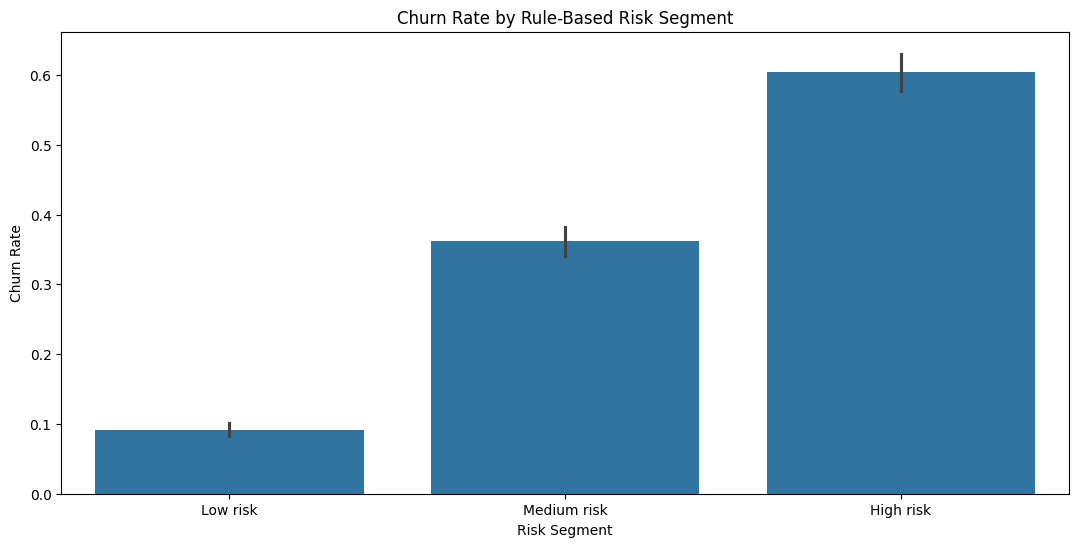

In [46]:
plt.figure(figsize=figsize)
sns.barplot(
    data=df_fe,
    x="rule_based_risk_segment",
    y="ChurnFlag",
    estimator=np.mean,
    order=["Low risk", "Medium risk", "High risk"]
)
plt.title("Churn Rate by Rule-Based Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Churn Rate")
plt.show()

The rule-based segment provides a simple business-oriented way to group customers by churn risk.

Customers classified as high risk combine several patterns observed in the EDA:

- Month-to-month contract.
- Electronic check payment.
- Fiber optic internet service.

This type of feature can be useful both for model training and for communicating insights to non-technical stakeholders.


## 6. Save Engineered Dataset and Conclusions

The engineered dataset is saved for the next notebook, where machine learning models will be trained and evaluated.

In [47]:
df_fe.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,tenure_group,monthly_charge_segment,has_internet_service,has_fiber_optic,has_online_security,has_tech_support,has_security_or_support,has_streaming_service,num_optional_services,is_month_to_month,has_long_term_contract,uses_electronic_check,uses_automatic_payment,avg_total_charge_per_month,high_monthly_value_customer,high_total_value_customer,rule_based_risk_segment
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,Low monthly charge,1,0,0,0,0,0,1,1,0,1,0,29.85,0,0,Medium risk
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,Medium monthly charge,1,0,1,0,1,0,2,0,1,0,0,55.57,0,0,Low risk
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,Medium monthly charge,1,0,1,0,1,0,2,1,0,0,0,54.08,0,0,Low risk
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,Medium monthly charge,1,0,1,1,1,0,3,0,1,0,1,40.91,0,0,Low risk
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,High monthly charge,1,1,0,0,0,0,0,1,0,1,0,75.83,0,0,High risk


In [49]:
OUTPUT_PATH = Path("../data/processed/telco_customer_churn_feature_engineered.csv")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_fe.to_csv(OUTPUT_PATH, index=False)

print(f"Engineered dataset saved at: {OUTPUT_PATH}")

Engineered dataset saved at: ..\data\processed\telco_customer_churn_feature_engineered.csv


## **Final EDA Conclusions**

The exploratory analysis suggests the following main churn patterns:

- Customers with month-to-month contracts have a much higher churn rate.
- Customers using electronic check as payment method show a high churn rate.
- Fiber optic customers churn more frequently than DSL or non-internet customers.
- Customers without online security or tech support are more likely to churn.
- Customers with lower tenure are more likely to leave.
- Higher monthly charges are associated with higher churn.
- Long-term contracts and automatic payment methods are associated with lower churn.

The feature engineering process created new variables related to:

- Customer lifecycle stage.
- Monthly charge segment.
- Internet service usage.
- Security and support availability.
- Number of optional services.
- Contract risk.
- Payment behavior.
- Customer value.
- Rule-based churn risk segment.